In [29]:
import numpy as np
import matplotlib.pyplot as plt

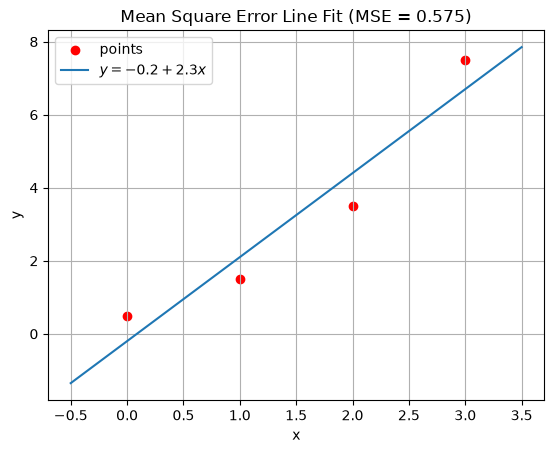

In [30]:
import numpy as np
import matplotlib.pyplot as plt

points = [(0, 0.5), (2, 3.5), (1, 1.5), (3, 7.5)]
xs, ys = map(np.array, zip(*points))

f = lambda x: -0.2 + 2.3 * x

mse = np.mean((ys - f(xs)) ** 2)

x = np.linspace(-0.5, 3.5, 200)

plt.scatter(xs, ys, color="red", label="points")
plt.plot(x, f(x), label="$y = -0.2 + 2.3x$")
plt.title(f"Mean Square Error Line Fit (MSE = {mse:.3f})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.savefig("media/line_fit.png", dpi=300, bbox_inches="tight")
plt.show()

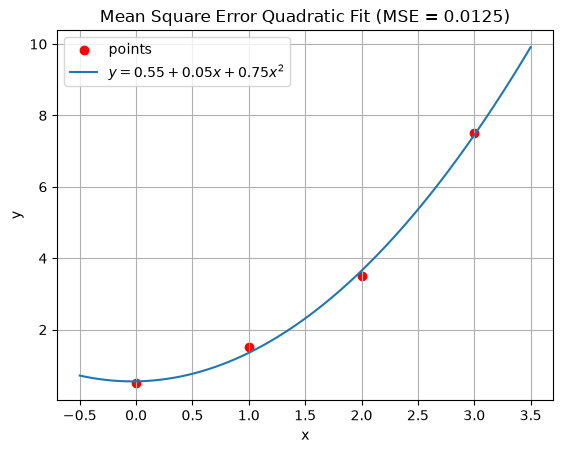

In [31]:
import numpy as np
import matplotlib.pyplot as plt

points = [(0, 0.5), (2, 3.5), (1, 1.5), (3, 7.5)]
xs, ys = map(np.array, zip(*points))

f = lambda x: 0.55 + 0.05 * x + 0.75 * x**2

mse = np.mean((ys - f(xs)) ** 2)

x = np.linspace(-0.5, 3.5, 200)

plt.scatter(xs, ys, color="red", label="points")
plt.plot(x, f(x), label="$y = 0.55 + 0.05x + 0.75x^2$")
plt.title(f"Mean Square Error Quadratic Fit (MSE = {mse:.4f})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.savefig("media/quadratic_fit.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
def newton_raphson(grad, hess, c0, mse=None, delta=1.0, tol=1e-7):
    c = np.asarray(c0, float)
    iterations = [{"c": c.copy(), "grad": grad(c),
                   "mse": mse(c) if mse else None, "step": None}]

    J_inv = np.linalg.inv(hess(c))
    c_new = c - delta * J_inv @ grad(c)

    while np.linalg.norm(c_new - c) > tol:
        step = np.linalg.norm(c_new - c)
        c = c_new
        g = grad(c)
        iterations.append({"c": c.copy(), "grad": g,
                           "mse": mse(c) if mse else None, "step": step})
        J_inv = np.linalg.inv(hess(c))
        c_new = c - delta * J_inv @ g
        
    return c_new, iterations

In [33]:
points = [(0, 0.5), (2, 3.5), (1, 1.5), (3, 7.5)]
x = np.array([p[0] for p in points], float)
y = np.array([p[1] for p in points], float)

def grad_E(c):
    return np.array([8 * c[0] + 12 * c[1] - 26,
                     12 * c[0] + 28 * c[1] - 62])

def hess_E(c):
    return np.array([[8, 12],
                     [12, 28]], float)

mse = lambda c: np.mean((y - c[0] - c[1] * x) ** 2)

c_hat, iterations = newton_raphson(grad_E, hess_E, c0=[0, 0], mse=mse, delta=0.5)

for k, it in enumerate(iterations):
    c_str = ", ".join(f"{v:.6f}" for v in it["c"])
    g_str = ", ".join(f"{v:.6f}" for v in it["grad"])
    print(f"{k:2d}  c=({c_str})  grad=({g_str})  mse={it['mse']:.6f}")

print("c_hat =", c_hat)

 0  c=(0.000000, 0.000000)  grad=(-26.000000, -62.000000)  mse=17.750000
 1  c=(-0.100000, 1.150000)  grad=(-13.000000, -31.000000)  mse=4.868750
 2  c=(-0.150000, 1.725000)  grad=(-6.500000, -15.500000)  mse=1.648437
 3  c=(-0.175000, 2.012500)  grad=(-3.250000, -7.750000)  mse=0.843359
 4  c=(-0.187500, 2.156250)  grad=(-1.625000, -3.875000)  mse=0.642090
 5  c=(-0.193750, 2.228125)  grad=(-0.812500, -1.937500)  mse=0.591772
 6  c=(-0.196875, 2.264063)  grad=(-0.406250, -0.968750)  mse=0.579193
 7  c=(-0.198438, 2.282031)  grad=(-0.203125, -0.484375)  mse=0.576048
 8  c=(-0.199219, 2.291016)  grad=(-0.101562, -0.242188)  mse=0.575262
 9  c=(-0.199609, 2.295508)  grad=(-0.050781, -0.121094)  mse=0.575066
10  c=(-0.199805, 2.297754)  grad=(-0.025391, -0.060547)  mse=0.575016
11  c=(-0.199902, 2.298877)  grad=(-0.012695, -0.030273)  mse=0.575004
12  c=(-0.199951, 2.299438)  grad=(-0.006348, -0.015137)  mse=0.575001
13  c=(-0.199976, 2.299719)  grad=(-0.003174, -0.007568)  mse=0.575000
1

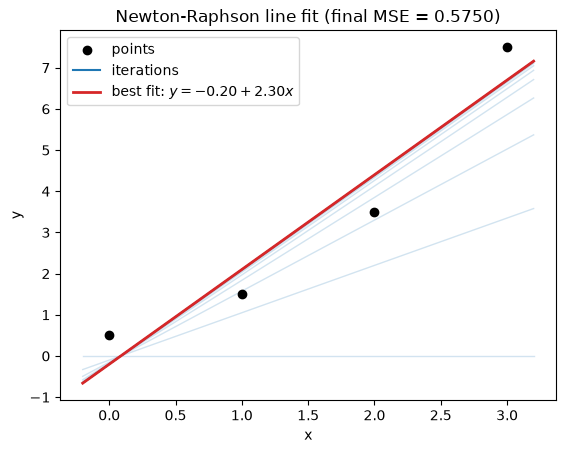

In [34]:
xs = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
mse_final = np.mean((y - c_hat[0] - c_hat[1] * x) ** 2)

plt.scatter(x, y, color="k", zorder=3, label="points")
for it in iterations:
    ci = it["c"]
    plt.plot(xs, ci[0] + ci[1] * xs, color="C0", lw=1, alpha=0.2)
plt.plot([], [], color="C0", label="iterations")

plt.plot(xs, c_hat[0] + c_hat[1] * xs, color="C3", lw=2,
         label=rf"best fit: $y = {c_hat[0]:.2f} + {c_hat[1]:.2f}x$")

plt.title(f"Newton-Raphson line fit (final MSE = {mse_final:.4f})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.savefig("media/line_fit_newton.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
points = [(0, 0.5), (2, 3.5), (1, 1.5), (3, 7.5)]
x = np.array([p[0] for p in points], float)
y = np.array([p[1] for p in points], float)

def grad_E(c):
    return np.array([8 * c[0] + 12 * c[1] + 28 * c[2] - 26,
                     12 * c[0] + 28 * c[1] + 72 * c[2] - 62,
                     28 * c[0] + 72 * c[1] + 196 * c[2] - 166])

def hess_E(c):
    return np.array([[8, 12, 28],
                     [12, 28, 72],
                     [28, 72, 196]], float)

mse = lambda c: np.mean((y - c[0] - c[1] * x - c[2] * x**2) ** 2)

c_hat, iterations = newton_raphson(grad_E, hess_E, c0=[0, 0, 0], mse=mse, delta=0.5)

for k, it in enumerate(iterations):
    c_str = ", ".join(f"{v:.6f}" for v in it["c"])
    g_str = ", ".join(f"{v:.6f}" for v in it["grad"])
    print(f"{k:2d}  c=({c_str})  grad=({g_str})  mse={it['mse']:.6f}")

print(f"c_hat = {c_hat},  final mse = {mse(c_hat):.6f}")

 0  c=(0.000000, 0.000000, 0.000000)  grad=(-26.000000, -62.000000, -166.000000)  mse=17.750000
 1  c=(0.275000, 0.025000, 0.375000)  grad=(-13.000000, -31.000000, -83.000000)  mse=4.446875
 2  c=(0.412500, 0.037500, 0.562500)  grad=(-6.500000, -15.500000, -41.500000)  mse=1.121094
 3  c=(0.481250, 0.043750, 0.656250)  grad=(-3.250000, -7.750000, -20.750000)  mse=0.289648
 4  c=(0.515625, 0.046875, 0.703125)  grad=(-1.625000, -3.875000, -10.375000)  mse=0.081787
 5  c=(0.532813, 0.048438, 0.726562)  grad=(-0.812500, -1.937500, -5.187500)  mse=0.029822
 6  c=(0.541406, 0.049219, 0.738281)  grad=(-0.406250, -0.968750, -2.593750)  mse=0.016830
 7  c=(0.545703, 0.049609, 0.744141)  grad=(-0.203125, -0.484375, -1.296875)  mse=0.013583
 8  c=(0.547852, 0.049805, 0.747070)  grad=(-0.101562, -0.242187, -0.648437)  mse=0.012771
 9  c=(0.548926, 0.049902, 0.748535)  grad=(-0.050781, -0.121094, -0.324219)  mse=0.012568
10  c=(0.549463, 0.049951, 0.749268)  grad=(-0.025391, -0.060547, -0.162109)  

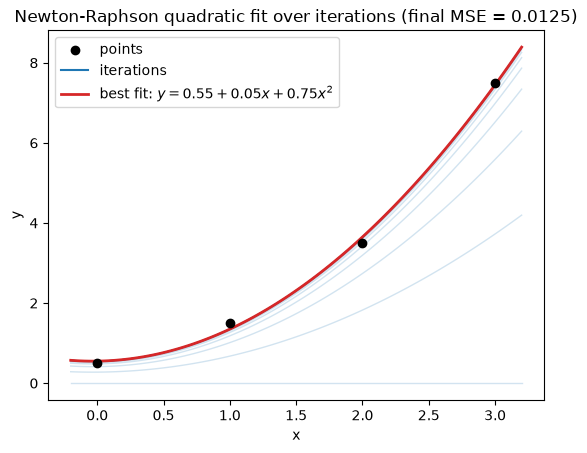

In [ ]:
xs = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
mse_final = np.mean((y - c_hat[0] - c_hat[1] * x - c_hat[2] * x**2) ** 2)

plt.scatter(x, y, color="k", zorder=3, label="points")
for it in iterations:
    ci = it["c"]
    plt.plot(xs, ci[0] + ci[1] * xs + ci[2] * xs**2, color="C0", lw=1, alpha=0.2)
plt.plot([], [], color="C0", label="iterations")

plt.plot(xs, c_hat[0] + c_hat[1] * xs + c_hat[2] * xs**2, color="C3", lw=2,
         label=rf"best fit: $y = {c_hat[0]:.2f} + {c_hat[1]:.2f}x + {c_hat[2]:.2f}x^2$")

plt.title(f"Newton-Raphson quadratic fit (final MSE = {mse_final:.4f})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.savefig("media/quadratic_fit_newton.png", dpi=300, bbox_inches="tight")
plt.show()